# 🎓 **CS331 <span style="color:#008080;"> PA Part 2 — Predicting Student Success with Logistic Regression</span>**  

Ever wondered what really determines a student’s grades? 📊   Is it their <span style="color:#f4a261;">love for AI/ML</span>, their <span style="color:#6baed6;">daily dose of chai</span>, or maybe just how many <span style="color:#2a9d8f;">friends</span> they have to "share" notes with? 👀  

In this assignment, you’ll you’ll put your Machine Learning hat and build a <span style="color:#008080;">Logistic Regression model</span> to find out! Your task is to use features like these to predict a student's grade — turning everyday student habits into mathematical insights. Who knows, by the end of this, you might even discover the secret formula for acing <span style="color:#457b9d;"> CS331</span> 😉

### Introduction

In this task, you will be Logistic Regression models for the provided dataset from scratch. A description of the problem statement is given at the start of each part. It is important that you display the output where asked. In case of no outputs, you will get a 0 for that part.

After this notebook you should be able to:

- Implement a classifier using Logistic Regression.

- Create a Logistic Regression model using simple `numpy`.

Have fun!

### Instructions

- Follow along with the notebook, filling out the necessary code where instructed.

- <span style="color: red;">Make sure to run all cells for credit.</span>

- <span style="color: red;">Do not remove any pre-written code.</span> 

- <span style="color: red;">You must attempt all parts.</span> Do not assume that because something is for 0 marks, you can leave it - it will definitely be used in later parts.

- <span style="color: red;">Do not use unauthorized libraries.</span> You are not allowed to use `sklearn` for anything except train-test split.

### One-vs-All Classification

<center>
  <img src = "https://miro.medium.com/v2/resize:fit:1100/format:webp/1*RElrybCZ4WPsUfRwDl7fqA.png">
</center>

One vs All (OvA) is a common technique to extend binary classifiers, like logistic regression, to handle multiclass classification tasks. For each class in the dataset, a logistic regression model is trained to distinguish that class from all other classes. For instance, for a `m` class classification, we will have `m` logistic regression classifiers in our pipeline. When making a prediction, each model outputs a probability that the instance belongs to its target class. The class with the highest probability across all models is chosen as the final prediction.

In this part, we will be going over how to implement a Multiclass Logistic Regression (OvA) model from scratch. For a review of this concept, you can go over the course slides or go over this [resource](https://www.cs.rice.edu/~as143/COMP642_Spring22/Scribes/Lect5).

## Import Libraries

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

## Dataset

Load the `students_data.csv` dataset and explore its features.

In [2]:
DATA_PATH = "students_data.csv"
df = pd.read_csv(DATA_PATH)  


# Preprocessing   [10 Marks]

In this step, you will need to make some changes to the dataset before we can proceed with the analysis. Follow the guidelines below:

1. **Perform Train-Test Split**:  
   Split the dataset into training and testing sets (8:2), and then check the sizes of both.  
   This step ensures that you have the right distribution of data for training and evaluation. Remember that `grade` is our target feature. **[5 Points]**

2. **Normalize Data**:  
   Utilize the `StandardScaler` class that you created in Part 1 to normalize the features of the dataset. **[10 Points]**

In [3]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        X= np.array(X, dtype= 'float')
        self.mean = np.mean(X, axis= 0)
        self.std = np.std(X, axis = 0)

    def transform(self, X):
        X = np.array(X, dtype= float)
        if self.mean is None or self.std is None:
            return X
        X_scaled = (X - self.mean) / self.std
        return X_scaled

X_raw = df.drop(columns=['grade'])   
y = df['grade']

X_train, X_test, y_train, y_test = train_test_split( X_raw, y, test_size= 0.2 , random_state= 42)

ssccaler = StandardScaler()
ssccaler.fit(X_train)
print(y_train.shape)
print(y_test.shape)
X_train_std = ssccaler.transform(X_train)
X_test_std = ssccaler.transform(X_test)


(400,)
(100,)


## Part A: Implementation from Scratch  [35 Marks]

### Theory recap (Logistic Regression)

- **Model**

  $$p(y=1\mid X)=\sigma(X\mathbf{w}+b), \qquad \sigma(z)=\frac{1}{1+e^{-z}}$$

- **Loss (Binary Cross-Entropy)**

  $$J(\mathbf{w}, b)=-\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log \hat{p}^{(i)}+\big(1-y^{(i)}\big)\log\!\big(1-\hat{p}^{(i)}\big)\Big], \qquad
  \hat{\mathbf{p}}=\sigma(X\mathbf{w}+b)$$

- **Gradients**

  $$\nabla_{\mathbf{w}} J=\frac{1}{m}X^{\top}\!\big(\hat{\mathbf{p}}-\mathbf{y}\big), \qquad
  \nabla_{b} J=\frac{1}{m}\sum_{i=1}^{m}\big(\hat{p}^{(i)}-y^{(i)}\big)$$

- **Update (Gradient Descent)**

  $$\mathbf{w}\leftarrow \mathbf{w}-\alpha\,\nabla_{\mathbf{w}}J, \qquad
  b\leftarrow b-\alpha\,\nabla_{b}J$$

Create a class, and implement the functionality described below to create a fully fledged **Regularized Logistic Regression model.**

* `sigmoid(x)`: This is the non-linear "activation" function that differentiates Logistic from plain-old Linear Regression. Refer to the formula from the slides. [5 Points]

* `cross_entropy_loss(y_true, y_pred)`: This is the loss function that will help you calculate the gradients for updating your model. Note that this is a Binary Classification task so you can use the Binary Cross Entropy function mentioned in the slides. You can include regularization if needed, remember to adjust the loss and gradients accordingly. [5 Points]

* `fit(x_train, y_train)`: This will be where you implement the Gradient Descent algorithm again, keeping in mind the differences between Linear and Logistic Regression. Keep track of losses for every iteration - you can save them in the class or return them. [5 points]

* `predict(x_test)`: predict whether the grade label is 0 or 1 for the student feature record using learned logistic regression (use the decision threshold of 0.5) **Note: you need to return the probability and the predicted label from this function** [5 Points]

* `evaluate(y_true, y_pred)` function that calculates classification accuracy, F1 Score and confusion matrix. You can use `sklearn.metrics` for this. [5 Points]

In [4]:
class RegularizedLogisticRegression:
    def __init__(self, lr=0.01, iterations=10000):
        """
        Parameters:
            lr (float): Learning rate; Step size for gradient descent
            iterations (int): Number of iterations
        """
        self.lr = lr;
        self.iterations = iterations;
        self.w = None;
        self.b = None;
        self.losses = []

    # Sigmoid activation function
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    # Binary Cross-Entropy Loss 
    def cross_entropy_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        loss = - (1/m) * np.sum(y_true * np.log(y_pred) + (1- y_true) * np.log(1 - y_pred))
        return loss
    
    # Fit model using gradient descent
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1,1)
        m,n = X.shape

        self.w = np.zeros((n,1))
        self.b = 0
        
        for i in range(self.iterations):
            z = X @ self.w + self.b    
            y_hat = self.sigmoid(z)
            
            gradientw = (1/m) * (X.T @ (y_hat -y))
            gradientbias = (1/m) * np.sum(y_hat -y)
            
            self.w -= self.lr * gradientw
            self.b -= self.lr * gradientbias
            
            loss =self.cross_entropy_loss(y, y_hat)
            self.losses.append(loss)
            
    def predict(self, X):
        X = np.array(X)
        probs = self.sigmoid(X @ self.w + self.b)
        labels = (probs >= 0.5).astype(int)
        return probs.ravel(), labels.ravel()

    # Evaluate model
    def evaluate(self, y_true, y_pred_labels):
        acc = accuracy_score(y_true, y_pred_labels)
        f1 = f1_score(y_true, y_pred_labels)
        cm = confusion_matrix(y_true, y_pred_labels)
        
        print("Accuracy:", acc)
        print("F1 Score:", f1)
        print("Confusion Matrix:", cm)
        return acc, f1, cm


# Implement One vs All Classification  [10 marks]

You need to build five classifiers (hint and please don't panic: it's just a loop) - one for each class (grade) and perform the following steps for each:

1. Create a plot with the number of iterations/epochs on the x-axis and training/validation loss on the y-axis for the evaluation dataset that we separated previously.

2. Tune the hyperparameters, i.e., learning rate and number of epochs, to minimize the train loss.

**Remember from the class that:** 
- Your Logistic Regression classifier is **binary** and you are trying to do one-vs-all classification, so the grade labels will need some tweaking for every classifier (make sure not to keep overwriting the same object!)

(Consult the class slides for details)

**Please note that the correctness of the functions you created previously depends on the plot. The curve should show a constant dip, eventually reaching a plateau.**


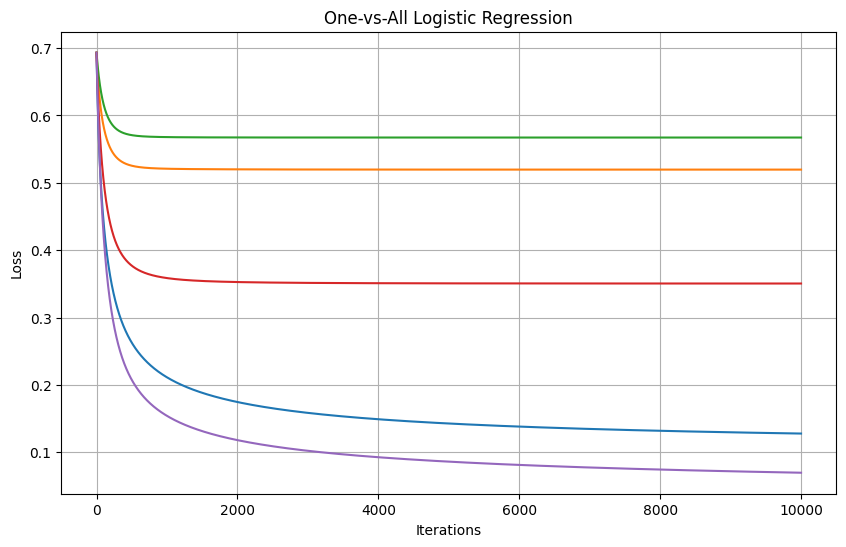

['A' 'B' 'C' 'D' 'E']


In [5]:
# Dictionary to store classifiers
classifiers = {}
classes = np.unique(y_train)

plt.figure(figsize=(10,6))

for cls in classes:
    y_train_binary = (y_train == cls).astype(int)
    y_test_binary = (y_test == cls).astype(int)
    
    model = RegularizedLogisticRegression(lr = 0.02, iterations= 10000)
    model.fit(X_train_std, y_train_binary)
    
    classifiers[cls] = model
    
    val_probs, _ = model.predict(X_test_std)
    val_loss = model.cross_entropy_loss(y_test_binary, val_probs)
    
    plt.plot(range(model.iterations), model.losses)

plt.title("One-vs-All Logistic Regression")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

print(np.unique(y_train))

# Evaluate  [15 Marks]

It's time to run your logistic regression model on the test dataset! 

### Class Wise Evaluation
First, evaluate each binary classifier individually on the test data. [10 marks]

In [6]:
# Evaluate each binary classifiers

for cls, model in classifiers.items():
    y_test_binary = (y_test == cls).astype(int)
    _, y_pred_binary = model.predict(X_test_std)
    acc, f1, cm = model.evaluate(y_test_binary, y_pred_binary)
    
    print(f"Class {cls} Results:")
    print(f"Accuracy: {acc}")
    print(f"F1 Score: {f1}")
    print("Confusion Matrix:", cm)

Accuracy: 0.91
F1 Score: 0.7096774193548387
Confusion Matrix: [[80  3]
 [ 6 11]]
Class A Results:
Accuracy: 0.91
F1 Score: 0.7096774193548387
Confusion Matrix: [[80  3]
 [ 6 11]]
Accuracy: 0.71
F1 Score: 0.06451612903225806
Confusion Matrix: [[70  5]
 [24  1]]
Class B Results:
Accuracy: 0.71
F1 Score: 0.06451612903225806
Confusion Matrix: [[70  5]
 [24  1]]
Accuracy: 0.66
F1 Score: 0.0
Confusion Matrix: [[66  6]
 [28  0]]
Class C Results:
Accuracy: 0.66
F1 Score: 0.0
Confusion Matrix: [[66  6]
 [28  0]]
Accuracy: 0.74
F1 Score: 0.1875
Confusion Matrix: [[71 13]
 [13  3]]
Class D Results:
Accuracy: 0.74
F1 Score: 0.1875
Confusion Matrix: [[71 13]
 [13  3]]
Accuracy: 0.95
F1 Score: 0.782608695652174
Confusion Matrix: [[86  0]
 [ 5  9]]
Class E Results:
Accuracy: 0.95
F1 Score: 0.782608695652174
Confusion Matrix: [[86  0]
 [ 5  9]]


### Multiclass Evaluation
The final stage (yayy you made it here!). 🪄✨

Perform multiclass evaluation and report macro F1, accuracy and confusion matrix [5 marks]

**Minimum acceptable performance is 0.6 Accuracy and 0.59 Macro-F1.**

In [7]:
all_probs = []
for cls, model in classifiers.items():
    probability, _ = model.predict(X_test_std)
    all_probs.append(probability)
    
all_probs = np.array(all_probs).T
y_pred_indices = np.argmax(all_probs, axis=1)
y_pred = classes[y_pred_indices]

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred, labels=classes)

print(f"Accuracy:", accuracy)
print(f"Macro F1 Score:", macro_f1)
print(f"confusion_matrix: ", cm)

Accuracy: 0.61
Macro F1 Score: 0.6086450317832052
confusion_matrix:  [[14  3  0  0  0]
 [ 4 16  5  0  0]
 [ 0  5 18  5  0]
 [ 0  0  9  6  1]
 [ 0  0  1  6  7]]


# Part B: Use Scikit-learn  [20 Marks]

In this part, use scikit-learn’s [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to train and test on your data.

Use scikit-learn’s `accuracy_score` function to calculate the [accuracy](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), F1 score and [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) function to calculate confusion matrix on test set.

Finally, plot the confusion matrix.

Accuracy: 0.66
Macro F1 Score: 0.6678234469103208
Confusion Matrix: [[11  6  0  0  0]
 [ 3 16  6  0  0]
 [ 0  3 21  4  0]
 [ 0  0  7  9  0]
 [ 0  0  0  5  9]]


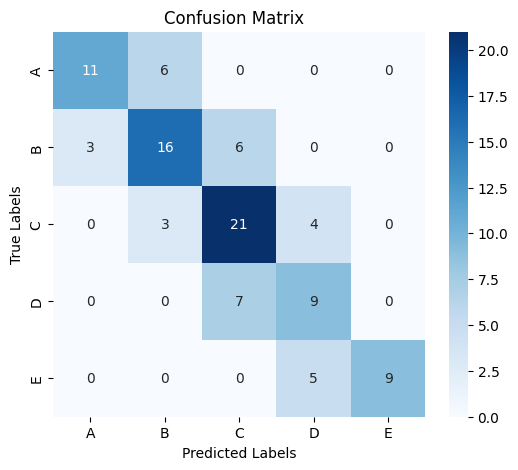

In [8]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X_train_std, y_train)
y_pred = clf.predict(X_test_std)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))

print(f"Accuracy:", accuracy)
print(f"Macro F1 Score:", macro_f1)
print("Confusion Matrix:", cm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.title("Confusion Matrix  ")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Part C: Will You Pass CS331?  [10 marks]
Use your multiclass classifier to predict whether you will pass the course!

If you don't like the answer, try tweaking things to see what you might need to fix in life :)

In [9]:
# Fill in these values (honestly! or at least creatively 😜)

# Your age in years
age = 20

# How many notebooks do you actually use vs. hoard for lecture notes? (0-4)
num_notebooks = 3

# Your circle of friends – the ride-or-die crew. (0-4)
num_friends = 3

# Travel time to campus. Pick wisely: 1=DHA gang, 4=have to wake up 2 hours before class.
travel_time = 1

# Daily chai dose (1-4 cups - sadly we have a range here. the imposters with 0, put 1 please)
chai_cups_daily = 1 

# Total F grades you’ve racked up (we won’t tell!). (0-3)
total_f_grades = 0

# Weekly hangouts (1-5)
hangouts = 0

# Number of societies you secretly (or not) participate in (1-5)
societies = 3

# TAships you've done so far (1-5)
TAships = 1

# How’s your health? 1=hmm, 3=bas chal raha hai, 5=can go to jammin for food every day. (1-5)
health =  3

# Count of absences – low is gold, high is…creative freedom. (0-33)
absences =  10

# Times you’ve cheated – strictly hypothetical! (0-18)
times_cheated = 1 

# Study hours per week (5-19)
study_time = 19

# Love for AI/ML – from “AI will destroy humans” to “I love the classes - or Dr. Agha :)” (0-17)
love_for_ai_ml = 17 

student_inputs = [age, num_notebooks, num_friends, travel_time, chai_cups_daily,
                  total_f_grades, hangouts, societies, TAships, health,
                  absences, times_cheated, study_time, love_for_ai_ml]
test_point = np.array([student_inputs])


In [10]:
# Normalise your data point and prepare it for classification
test_point_std = ssccaler.transform(test_point)

In [11]:
# Run the classification
all_probs = []
for cls, model in classifiers.items():
    prob, _ = model.predict(test_point_std)
    all_probs.append(prob)

all_probs = np.array(all_probs).T
pred_index = np.argmax(all_probs, axis=1)
predicted_class = classes[pred_index][0]

print("My Predicted grade -_-:", predicted_class)
print("YAYYY")



My Predicted grade -_-: A
YAYYY
